In [26]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Data

In [27]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_CC_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_CC_miRNA.h5ad")

# load capture
beta = np.loadtxt("../HEK293T/TotalX_HEK293T_capture.txt")
beta_G1 = np.loadtxt("TotalX_HEK293T_G1_capture.txt")
beta_S = np.loadtxt("TotalX_HEK293T_S_capture.txt")
beta_G2M = np.loadtxt("TotalX_HEK293T_G2M_capture.txt")

## Additional miRNA Selection

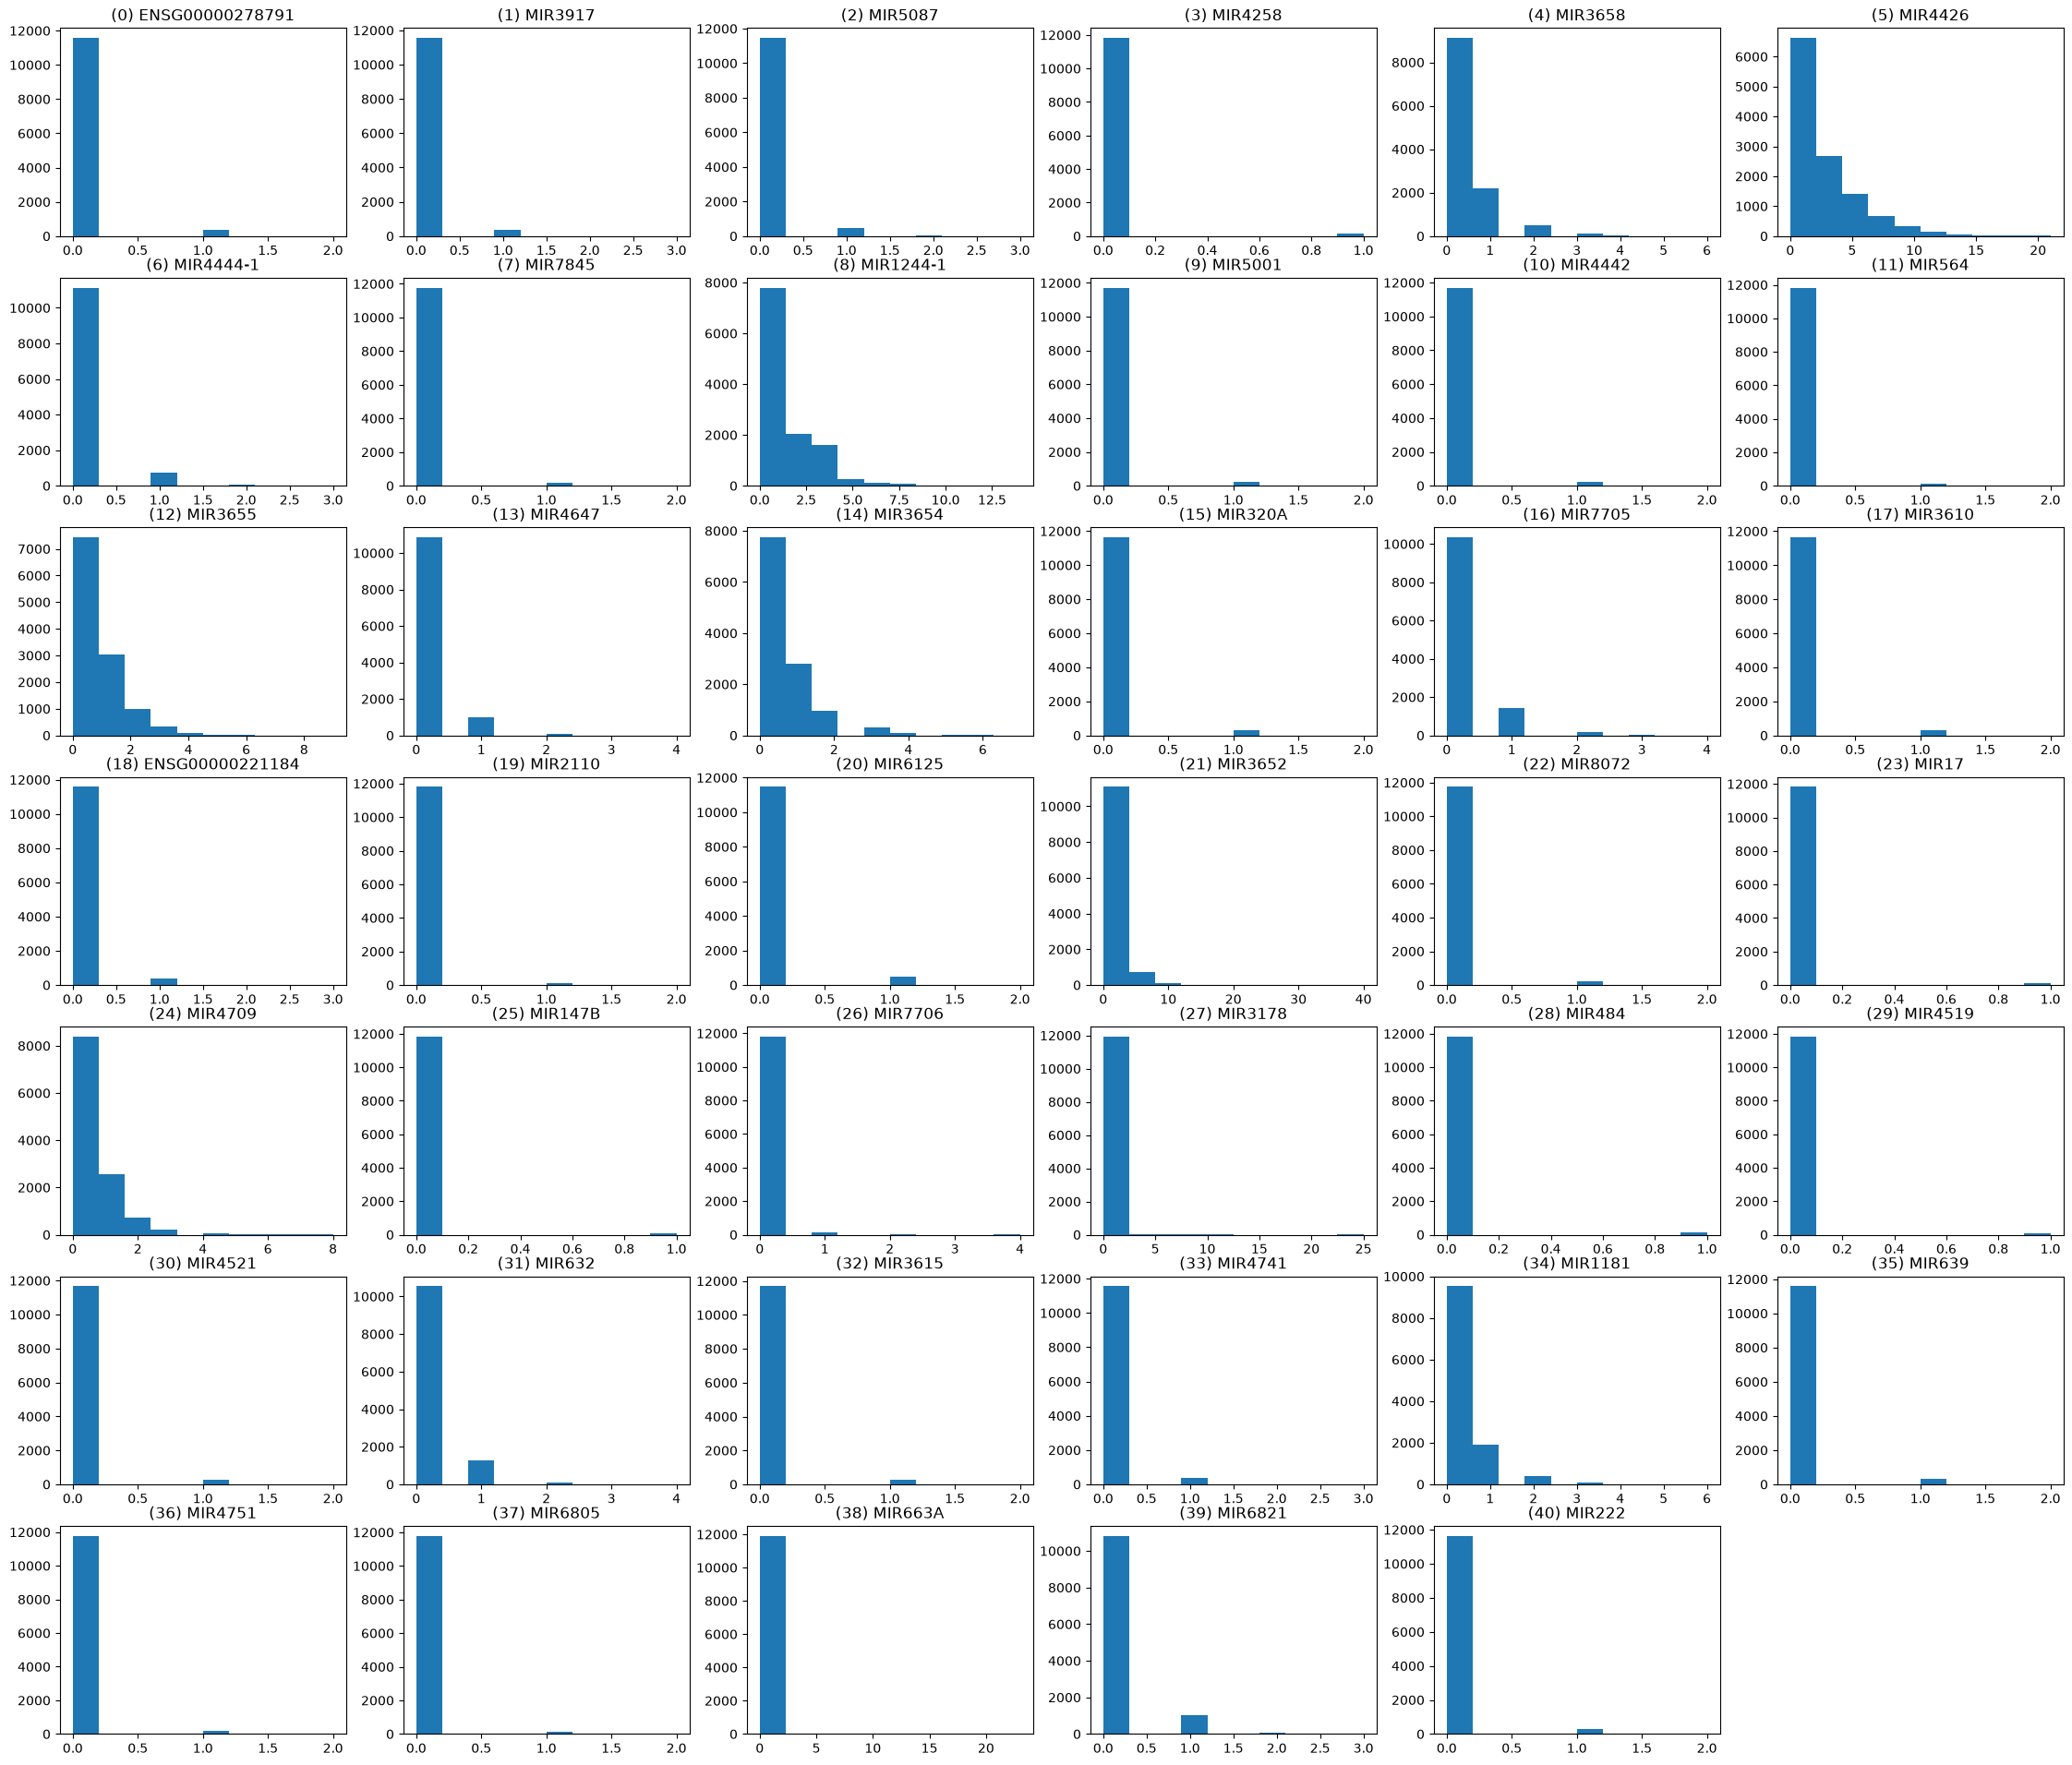

In [28]:
# miRNA distributions
M, N = 7, 6
fig, axs = plt.subplots(M, N, figsize=(7 * 4, 6 * 4))
k = 0
for i in range(M):
    for j in range(N):
        if k == 41:
            axs[i, j].axis('off')
            break
        data = adata_miRNA[:, k]
        sample = data.X.toarray()
        axs[i, j].hist(sample)
        axs[i, j].set_title(f"({k}) {data.var['GeneName'].iloc[0]}")
        k += 1
plt.show()

Many miRNA have observed counts of only {0, 1} or very few higher, giving very little information to analyse

For now restrict to miRNA with a maximum observed count of at least 3

(can easily analyse those removed and append to results)

In [29]:
# max observed count per miRNA
max_count = adata_miRNA.X.max(axis=0).toarray()

# select
count_mask = (max_count >= 3).squeeze()
miRNA_idxs = np.arange(len(count_mask))[count_mask]

# subset miRNA
adata_miRNA = adata_miRNA[:, miRNA_idxs]

# display
print(f"{sum(count_mask)} / {len(count_mask)} miRNA retained")

20 / 41 miRNA retained


# miRNA - miRNA correlations

- look at observed expression to see if any mutual exclusion
- look at correlation matrices OB / OG over all and per cell cycle phase

In [5]:
# consider all miRNA (additional selection)
L = adata_miRNA.n_vars

# select all gene pairs: no repeats
Is, Js = np.triu_indices(L, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# initialize dataset
SDP_data = SDP_miRNA.dataset.Dataset()
SDP_data_G1 = SDP_miRNA.dataset.Dataset()
SDP_data_S = SDP_miRNA.dataset.Dataset()
SDP_data_G2M = SDP_miRNA.dataset.Dataset()

# construct pairs
SDP_data.construct_dataset_adata(adata_miRNA, adata_miRNA, beta, gene_queries)
SDP_data_G1.construct_dataset_adata(adata_miRNA[adata_miRNA.obs['phase'] == "G1"], adata_miRNA[adata_miRNA.obs['phase'] == "G1"], beta_G1, gene_queries)
SDP_data_S.construct_dataset_adata(adata_miRNA[adata_miRNA.obs['phase'] == "S"], adata_miRNA[adata_miRNA.obs['phase'] == "S"], beta_S, gene_queries)
SDP_data_G2M.construct_dataset_adata(adata_miRNA[adata_miRNA.obs['phase'] == "G2M"], adata_miRNA[adata_miRNA.obs['phase'] == "G2M"], beta_G2M, gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)
SDP_data_G1.bootstrap(d=3)
SDP_data_S.bootstrap(d=3)
SDP_data_G2M.bootstrap(d=3)

100%|██████████| 2/2 [00:00<00:00,  3.86it/s]


In [6]:
# model free independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=3)
MF_ind.optimized_construction = True
MF_ind.analyse_dataset()

MF_ind_G1 = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G1, d=3)
MF_ind_G1.optimized_construction = True
MF_ind_G1.analyse_dataset()

MF_ind_S = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_S, d=3)
MF_ind_S.optimized_construction = True
MF_ind_S.analyse_dataset()

MF_ind_G2M = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G2M, d=3)
MF_ind_G2M.optimized_construction = True
MF_ind_G2M.analyse_dataset()

100%|██████████| 190/190 [00:00<00:00, 227.49it/s]


In [10]:
# model free interacting H&R
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
#MF_int.use_optimized_hit_and_run = True
MF_int.analyse_dataset()

MF_int_G1 = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G1, d=3)
#MF_int_G1.use_optimized_hit_and_run = True
MF_int_G1.analyse_dataset()

MF_int_S = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_S, d=3)
#MF_int_S.use_optimized_hit_and_run = True
MF_int_S.analyse_dataset()

MF_int_G2M = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G2M, d=3)
#MF_int_G2M.use_optimized_hit_and_run = True
MF_int_G2M.analyse_dataset()

  0%|          | 0/190 [00:00<?, ?it/s]

100%|██████████| 190/190 [00:57<00:00,  3.32it/s]


In [ ]:
# optimized H&R code
for opt in [MF_int, MF_int_G1, MF_int_S, MF_int_G2M]:
    print(f"Interval err: {np.unique([dct['err'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}")
    print(f"Interval eps: {np.unique([dct['eps'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}\n")

Interval err: (array([0]), array([190]))
Interval eps: (array([0]), array([190]))

Interval err: (array([999]), array([190]))
Interval eps: (array([0]), array([190]))

Interval err: (array([0]), array([190]))
Interval eps: (array([  0, 999]), array([189,   1]))

Interval err: (array([0]), array([190]))
Interval eps: (array([0]), array([190]))



In [13]:
# current H&R code
for opt in [MF_int, MF_int_G1, MF_int_S, MF_int_G2M]:
    print(f"Interval err: {np.unique([dct['err'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}")
    print(f"Interval eps: {np.unique([dct['eps'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}\n")

Interval err: (array([0]), array([190]))
Interval eps: (array([0]), array([190]))

Interval err: (array([0]), array([190]))
Interval eps: (array([  0, 999]), array([158,  32]))

Interval err: (array([0]), array([190]))
Interval eps: (array([  0, 999]), array([189,   1]))

Interval err: (array([0]), array([190]))
Interval eps: (array([0]), array([190]))



In [12]:
# H&R correlations
_, HAR_intervals = MF_int.compute_dataset_correlation()
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

_, HAR_intervals_G1 = MF_int_G1.compute_dataset_correlation()
HAR_mid_G1 = (HAR_intervals_G1[:, 0] + HAR_intervals_G1[:, 1]) / 2

_, HAR_intervals_S = MF_int_S.compute_dataset_correlation()
HAR_mid_S = (HAR_intervals_S[:, 0] + HAR_intervals_S[:, 1]) / 2

_, HAR_intervals_G2M = MF_int_G2M.compute_dataset_correlation()
HAR_mid_G2M = (HAR_intervals_G2M[:, 0] + HAR_intervals_G2M[:, 1]) / 2

100%|██████████| 190/190 [00:01<00:00, 102.17it/s]


In [14]:
all_matrix_mid = np.zeros((L, L)) * np.nan
G1_matrix_mid = np.zeros((L, L)) * np.nan
S_matrix_mid = np.zeros((L, L)) * np.nan
G2M_matrix_mid = np.zeros((L, L)) * np.nan

all_matrix_lb = np.zeros((L, L)) * np.nan
G1_matrix_lb = np.zeros((L, L)) * np.nan
S_matrix_lb = np.zeros((L, L)) * np.nan
G2M_matrix_lb = np.zeros((L, L)) * np.nan

all_matrix_ub = np.zeros((L, L)) * np.nan
G1_matrix_ub = np.zeros((L, L)) * np.nan
S_matrix_ub = np.zeros((L, L)) * np.nan
G2M_matrix_ub = np.zeros((L, L)) * np.nan

for i, query in enumerate(SDP_data.gene_queries):
    if MF_ind.result_dict[i]['status'] == "INFEASIBLE":
        all_matrix_mid[query[0][0], query[1][0]] = HAR_mid[i]
        all_matrix_lb[query[0][0], query[1][0]] = HAR_intervals[i, 0]
        all_matrix_ub[query[0][0], query[1][0]] = HAR_intervals[i, 1]
    if MF_ind_G1.result_dict[i]['status'] == "INFEASIBLE":
        G1_matrix_mid[query[0][0], query[1][0]] = HAR_mid_G1[i]
        G1_matrix_lb[query[0][0], query[1][0]] = HAR_intervals_G1[i, 0]
        G1_matrix_ub[query[0][0], query[1][0]] = HAR_intervals_G1[i, 1]
    if MF_ind_S.result_dict[i]['status'] == "INFEASIBLE":
        S_matrix_mid[query[0][0], query[1][0]] = HAR_mid_S[i]
        S_matrix_lb[query[0][0], query[1][0]] = HAR_intervals_S[i, 0]
        S_matrix_ub[query[0][0], query[1][0]] = HAR_intervals_S[i, 1]
    if MF_ind_G2M.result_dict[i]['status'] == "INFEASIBLE":
        G2M_matrix_mid[query[0][0], query[1][0]] = HAR_mid_G2M[i]
        G2M_matrix_lb[query[0][0], query[1][0]] = HAR_intervals_G2M[i, 0]
        G2M_matrix_ub[query[0][0], query[1][0]] = HAR_intervals_G2M[i, 1]

In [15]:
def miRNA_heatmat_plot(all_matrix, G1_matrix, S_matrix, G2M_matrix, stat):

    cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
    fig, axs = plt.subplots(1, 5, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}, constrained_layout=True)
    im = axs[0].imshow(all_matrix, cmap=cmap, vmin=-1, vmax=1)
    im = axs[1].imshow(G1_matrix, cmap=cmap, vmin=-1, vmax=1)
    im = axs[2].imshow(S_matrix, cmap=cmap, vmin=-1, vmax=1)
    im = axs[3].imshow(G2M_matrix, cmap=cmap, vmin=-1, vmax=1)
    axs[0].set_xlabel("All cells")
    axs[1].set_xlabel("G1")
    axs[2].set_xlabel("S")
    axs[3].set_xlabel("G2M")
    RNA_labels = adata_miRNA.var['GeneName'].tolist()
    for i in range(4):
        axs[i].set_xticks(range(L))
        axs[i].set_xticklabels([""] * L, rotation=90)
        axs[i].set_yticks(range(L))
        axs[i].set_yticklabels([""] * L)
    axs[0].set_yticklabels(RNA_labels)
    fig.supxlabel("Cell Cycle Phase")
    fig.suptitle("microRNA - microRNA correlations")
    plt.colorbar(im, cax=axs[4], label=f"Correlation (H&R {stat})")
    plt.show()

## Correlation midpoint

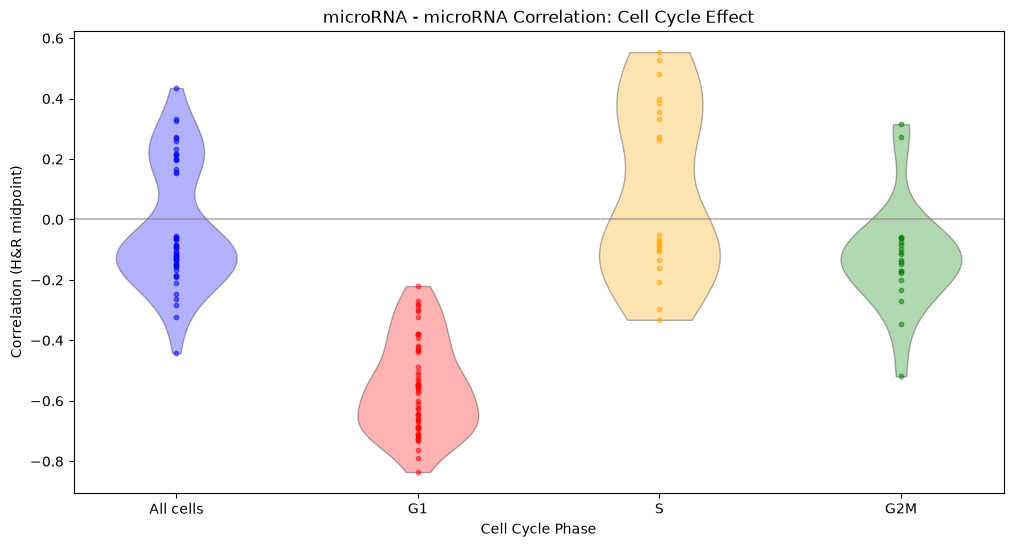

In [16]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "red", "orange", "green"]
plot_data_list = [
    all_matrix_mid[np.triu_indices(L, k=1)],
    G1_matrix_mid[np.triu_indices(L, k=1)],
    S_matrix_mid[np.triu_indices(L, k=1)],
    G2M_matrix_mid[np.triu_indices(L, k=1)]
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
    plt.scatter([i] * len(plot_data), plot_data, color=plot_colors[i], alpha=0.5, s=10)
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation (H&R midpoint)")
axs.set_title("microRNA - microRNA Correlation: Cell Cycle Effect")
plt.show()

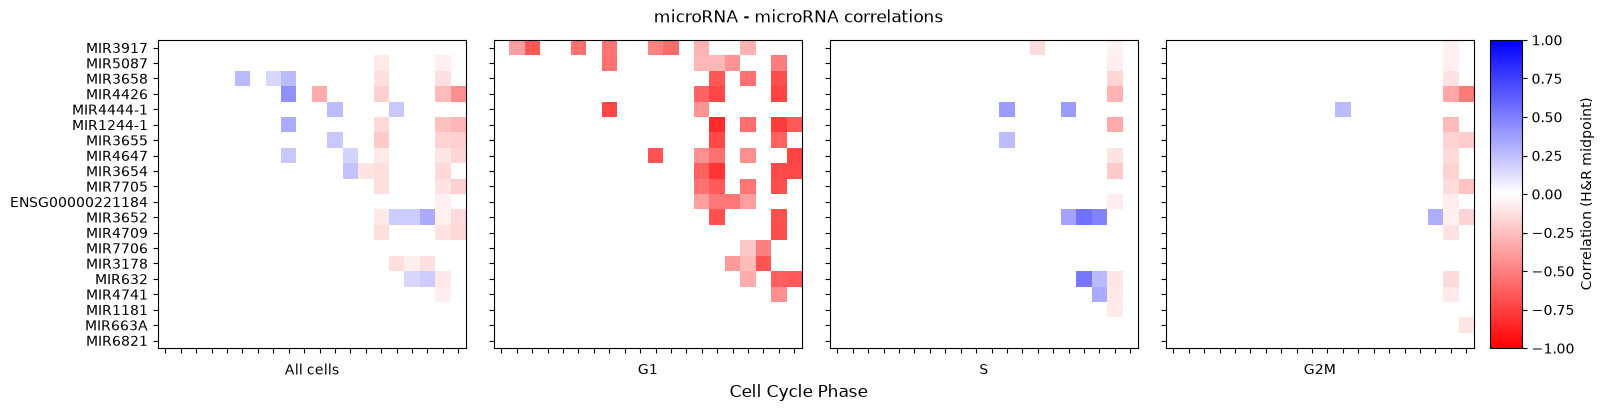

In [17]:
miRNA_heatmat_plot(all_matrix_mid, G1_matrix_mid, S_matrix_mid, G2M_matrix_mid, "midpoint")

## Correlation Intervals

In [18]:
np.nanmean(G1_matrix_ub - G1_matrix_lb)

np.float64(0.26541418379570697)

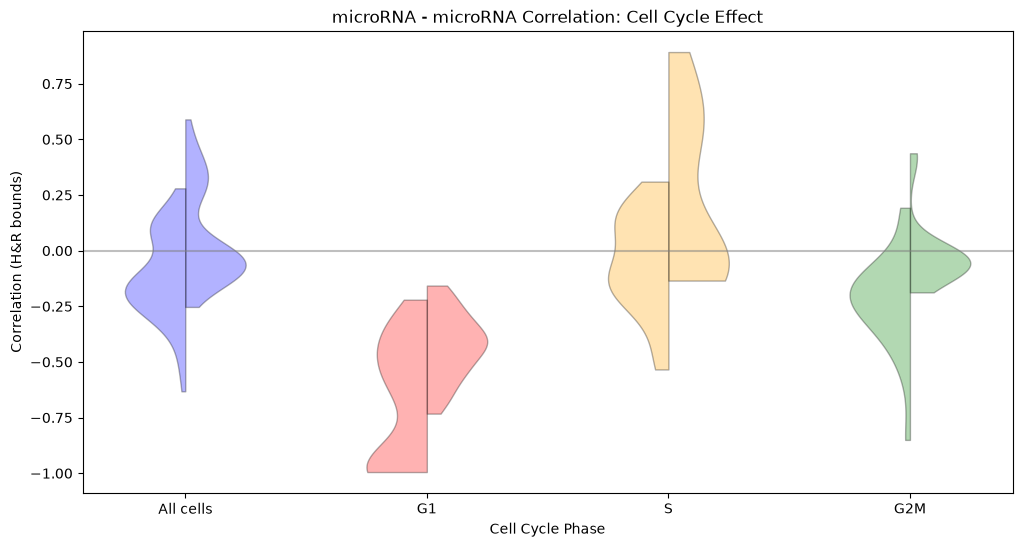

In [19]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "red", "orange", "green"]
plot_data_list_lb = [
    all_matrix_lb[np.triu_indices(L, k=1)],
    G1_matrix_lb[np.triu_indices(L, k=1)],
    S_matrix_lb[np.triu_indices(L, k=1)],
    G2M_matrix_lb[np.triu_indices(L, k=1)]
]
plot_data_list_ub = [
    all_matrix_ub[np.triu_indices(L, k=1)],
    G1_matrix_ub[np.triu_indices(L, k=1)],
    S_matrix_ub[np.triu_indices(L, k=1)],
    G2M_matrix_ub[np.triu_indices(L, k=1)]
]
for i, (plot_data_lb, plot_data_ub) in enumerate(zip(plot_data_list_lb, plot_data_list_ub)):
    vp = axs.violinplot(
        dataset=plot_data_lb,
        positions=[i],
        showextrema=False,
        side="low"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
    vp = axs.violinplot(
        dataset=plot_data_ub,
        positions=[i],
        showextrema=False,
        side="high"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation (H&R bounds)")
axs.set_title("microRNA - microRNA Correlation: Cell Cycle Effect")
plt.show()

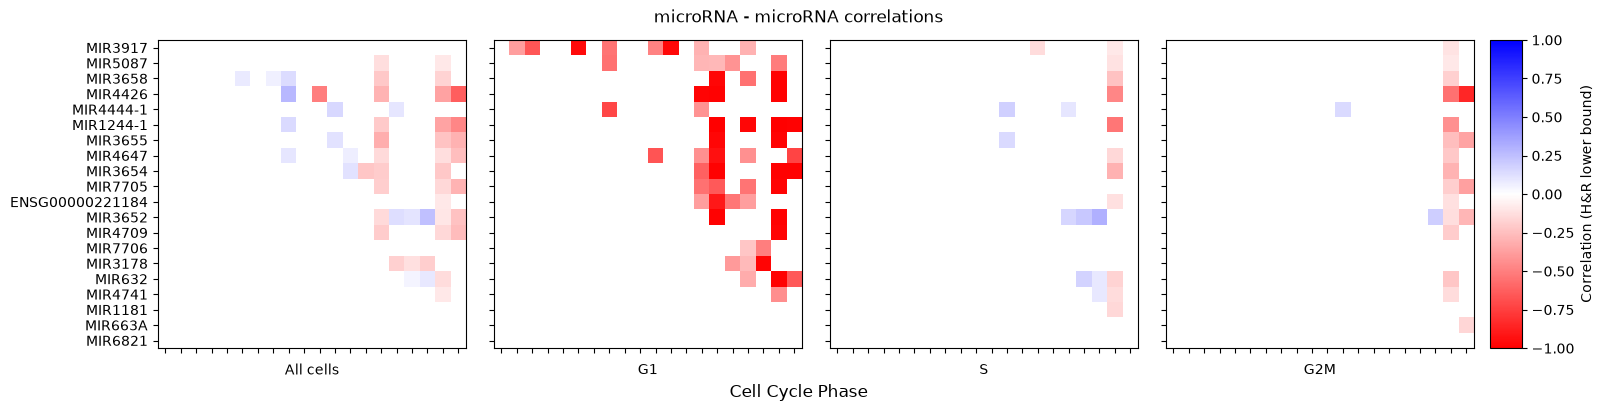

In [20]:
miRNA_heatmat_plot(all_matrix_lb, G1_matrix_lb, S_matrix_lb, G2M_matrix_lb, "lower bound")

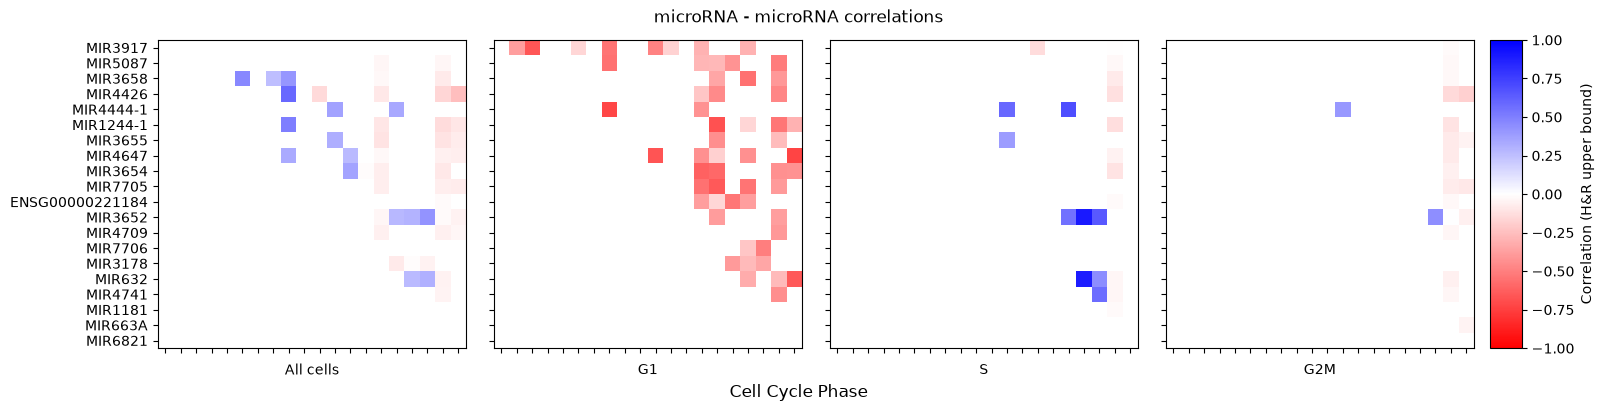

In [21]:
miRNA_heatmat_plot(all_matrix_ub, G1_matrix_ub, S_matrix_ub, G2M_matrix_ub, "upper bound")

## Exploration

In [22]:
# look at strongest negative correlation pair from G1
# look at observed count scatter and correlation

In [23]:
# strongest negatively correlated microRNAs
idx = np.nanargmin(G1_matrix_mid)
idx // L, idx % L

(np.int64(5), np.int64(14))

In [24]:
# recovered correlation
G1_matrix_mid[5, 14], G1_matrix_lb[5, 14], G1_matrix_ub[5, 14]

(np.float64(-0.835636715416646),
 np.float64(-0.9924491047146139),
 np.float64(-0.6788243261186779))

In [25]:
# observed correlation
np.corrcoef(adata_miRNA[adata_miRNA.obs['phase'] == "G1", [5, 14]].X.toarray().T)[0, 1]

np.float64(-0.08420901430410785)

In [26]:
# correlation in other phases
all_matrix_mid[5, 14], S_matrix_mid[5, 14], G2M_matrix_mid[5, 14]

(np.float64(-0.1489023519564709), np.float64(nan), np.float64(nan))

In [27]:
# most extreme microRNA 5 count: corresponding microRNA 14 count and cell capture
idx = adata_miRNA[adata_miRNA.obs['phase'] == "G1", 5].X.toarray().argmax()
adata_miRNA[adata_miRNA.obs['phase'] == "G1", 5].X.toarray()[idx], adata_miRNA[adata_miRNA.obs['phase'] == "G1", 14].X.toarray()[idx], beta_G1[idx]

(array([6.], dtype=float32),
 array([0.], dtype=float32),
 np.float64(0.3190630078315735))

In [28]:
# most extreme microRNA 14 count: corresponding microRNA 5 count and cell capture
idx = adata_miRNA[adata_miRNA.obs['phase'] == "G1", 14].X.toarray().argmax()
adata_miRNA[adata_miRNA.obs['phase'] == "G1", 14].X.toarray()[idx], adata_miRNA[adata_miRNA.obs['phase'] == "G1", 5].X.toarray()[idx], beta_G1[idx]

(array([25.], dtype=float32),
 array([0.], dtype=float32),
 np.float64(0.8779544830322266))

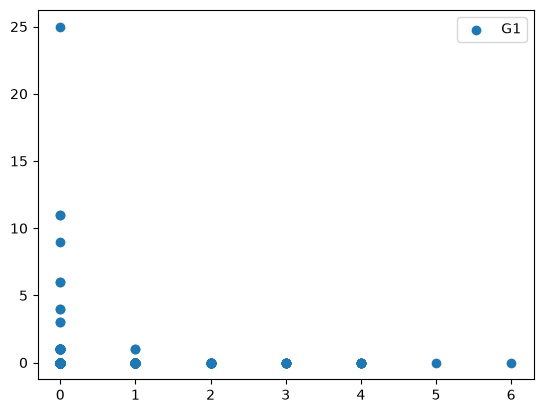

In [29]:
# scatter
plt.scatter(*adata_miRNA[adata_miRNA.obs['phase'] == "G1", [5, 14]].X.toarray().T, label="G1")
plt.legend()

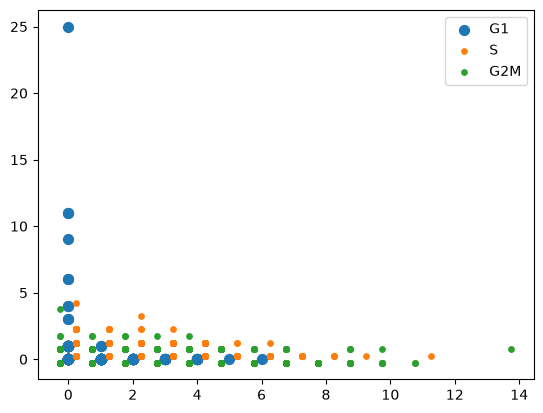

In [30]:
# scatter inlcuding other phases
plt.scatter(*adata_miRNA[adata_miRNA.obs['phase'] == "G1", [5, 14]].X.toarray().T, s=50, label="G1")
plt.scatter(*adata_miRNA[adata_miRNA.obs['phase'] == "S", [5, 14]].X.toarray().T + 0.25, s=15, label="S")
plt.scatter(*adata_miRNA[adata_miRNA.obs['phase'] == "G2M", [5, 14]].X.toarray().T - 0.25, s=15, label="G2M")
plt.legend()

# miRNA - mRNA correlations

- standard target correlations
- run independnce test, then only on dependent pairs run correlation recovery

## Running optimization

In [5]:
def miRNA_mRNA_correlation_pipeline(miRNA):

    # settings
    d = 3

    # get pcRNA names
    pcRNA_names = adata_pcRNA.var['GeneName'].tolist()

    # initialize result dataframes
    MF_ind_df = pd.DataFrame(index=pcRNA_names)
    MF_int_df = pd.DataFrame(index=pcRNA_names)

    # initialize datasets
    SDP_data = SDP_miRNA.dataset.Dataset()
    SDP_data_G1 = SDP_miRNA.dataset.Dataset()
    SDP_data_S = SDP_miRNA.dataset.Dataset()
    SDP_data_G2M = SDP_miRNA.dataset.Dataset()

    # construct datasets
    SDP_data.construct_dataset_adata(
        adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA],
        adata_pcRNA,
        beta
    )
    SDP_data_G1.construct_dataset_adata(
        adata_miRNA[adata_miRNA.obs['phase'] == "G1", adata_miRNA.var['GeneName'] == miRNA],
        adata_pcRNA[adata_pcRNA.obs['phase'] == "G1", :],
        beta_G1
    )
    SDP_data_S.construct_dataset_adata(
        adata_miRNA[adata_miRNA.obs['phase'] == "S", adata_miRNA.var['GeneName'] == miRNA],
        adata_pcRNA[adata_pcRNA.obs['phase'] == "S", :],
        beta_S
    )
    SDP_data_G2M.construct_dataset_adata(
        adata_miRNA[adata_miRNA.obs['phase'] == "G2M", adata_miRNA.var['GeneName'] == miRNA],
        adata_pcRNA[adata_pcRNA.obs['phase'] == "G2M", :],
        beta_G2M
    )

    # bootstrap
    SDP_data.bootstrap(d=d)
    SDP_data_G1.bootstrap(d=d)
    SDP_data_S.bootstrap(d=d)
    SDP_data_G2M.bootstrap(d=d)

    # model free independence test
    MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=d)
    MF_ind.optimized_construction = True
    MF_ind.analyse_dataset()

    MF_ind_G1 = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G1, d=d)
    MF_ind_G1.optimized_construction = True
    MF_ind_G1.analyse_dataset()

    MF_ind_S = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_S, d=d)
    MF_ind_S.optimized_construction = True
    MF_ind_S.analyse_dataset()

    MF_ind_G2M = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G2M, d=d)
    MF_ind_G2M.optimized_construction = True
    MF_ind_G2M.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in MF_ind.result_dict.values()])
    status_G1 = np.array([sol['status'] for sol in MF_ind_G1.result_dict.values()])
    status_S = np.array([sol['status'] for sol in MF_ind_S.result_dict.values()])
    status_G2M = np.array([sol['status'] for sol in MF_ind_G2M.result_dict.values()])

    # store
    MF_ind_df[f'{miRNA}_All_status'] = status
    MF_ind_df[f'{miRNA}_G1_status'] = status_G1
    MF_ind_df[f'{miRNA}_S_status'] = status_S
    MF_ind_df[f'{miRNA}_G2M_status'] = status_G2M

    # select indices of interacting pairs
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]
    int_idxs_G1 = np.arange(status_G1.size)[status_G1 == "INFEASIBLE"]
    int_idxs_S = np.arange(status_S.size)[status_S == "INFEASIBLE"]
    int_idxs_G2M = np.arange(status_G2M.size)[status_G2M == "INFEASIBLE"]
    
    # reduce gene queries to these
    gene_queries = [query for i, query in enumerate(SDP_data.gene_queries) if i in int_idxs]
    gene_queries_G1 = [query for i, query in enumerate(SDP_data_G1.gene_queries) if i in int_idxs_G1]
    gene_queries_S = [query for i, query in enumerate(SDP_data_S.gene_queries) if i in int_idxs_S]
    gene_queries_G2M = [query for i, query in enumerate(SDP_data_G2M.gene_queries) if i in int_idxs_G2M]

    # reduce dataset to interacting pairs
    SDP_data.gene_queries = gene_queries
    SDP_data.total_gene_queries = len(gene_queries)
    SDP_data.moment_bounds = SDP_data.moment_bounds[:, int_idxs, :]

    SDP_data_G1.gene_queries = gene_queries_G1
    SDP_data_G1.total_gene_queries = len(gene_queries_G1)
    SDP_data_G1.moment_bounds = SDP_data_G1.moment_bounds[:, int_idxs_G1, :]

    SDP_data_S.gene_queries = gene_queries_S
    SDP_data_S.total_gene_queries = len(gene_queries_S)
    SDP_data_S.moment_bounds = SDP_data_S.moment_bounds[:, int_idxs_S, :]

    SDP_data_G2M.gene_queries = gene_queries_G2M
    SDP_data_G2M.total_gene_queries = len(gene_queries_G2M)
    SDP_data_G2M.moment_bounds = SDP_data_G2M.moment_bounds[:, int_idxs_G2M, :]

    # model free interacting H&R
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=d)
    MF_int.analyse_dataset()

    MF_int_G1 = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G1, d=d)
    MF_int_G1.analyse_dataset()

    MF_int_S = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_S, d=d)
    MF_int_S.analyse_dataset()

    MF_int_G2M = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G2M, d=d)
    MF_int_G2M.analyse_dataset()
    
    # H&R correlations
    _, HAR_intervals = MF_int.compute_dataset_correlation()
    HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

    _, HAR_intervals_G1 = MF_int_G1.compute_dataset_correlation()
    HAR_mid_G1 = (HAR_intervals_G1[:, 0] + HAR_intervals_G1[:, 1]) / 2

    _, HAR_intervals_S = MF_int_S.compute_dataset_correlation()
    HAR_mid_S = (HAR_intervals_S[:, 0] + HAR_intervals_S[:, 1]) / 2

    _, HAR_intervals_G2M = MF_int_G2M.compute_dataset_correlation()
    HAR_mid_G2M = (HAR_intervals_G2M[:, 0] + HAR_intervals_G2M[:, 1]) / 2

    # embedd MF int results (only on interacting pairs) into array of all pairs
    HAR_all = np.empty((adata_pcRNA.n_vars, 12)) * np.nan
    HAR_all[int_idxs, 0] = HAR_intervals[:, 0]
    HAR_all[int_idxs, 1] = HAR_intervals[:, 1]
    HAR_all[int_idxs, 2] = HAR_mid
    HAR_all[int_idxs_G1, 3] = HAR_intervals_G1[:, 0]
    HAR_all[int_idxs_G1, 4] = HAR_intervals_G1[:, 1]
    HAR_all[int_idxs_G1, 5] = HAR_mid_G1
    HAR_all[int_idxs_S, 6] = HAR_intervals_S[:, 0]
    HAR_all[int_idxs_S, 7] = HAR_intervals_S[:, 1]
    HAR_all[int_idxs_S, 8] = HAR_mid_S
    HAR_all[int_idxs_G2M, 9] = HAR_intervals_G2M[:, 0]
    HAR_all[int_idxs_G2M, 10] = HAR_intervals_G2M[:, 1]
    HAR_all[int_idxs_G2M, 11] = HAR_mid_G2M

    # store
    MF_int_df[f'{miRNA}_All_HAR_min'] = HAR_all[:, 0]
    MF_int_df[f'{miRNA}_All_HAR_max'] = HAR_all[:, 1]
    MF_int_df[f'{miRNA}_All_HAR_mid'] = HAR_all[:, 2]
    MF_int_df[f'{miRNA}_G1_HAR_min'] = HAR_all[:, 3]
    MF_int_df[f'{miRNA}_G1_HAR_max'] = HAR_all[:, 4]
    MF_int_df[f'{miRNA}_G1_HAR_mid'] = HAR_all[:, 5]
    MF_int_df[f'{miRNA}_S_HAR_min'] = HAR_all[:, 6]
    MF_int_df[f'{miRNA}_S_HAR_max'] = HAR_all[:, 7]
    MF_int_df[f'{miRNA}_S_HAR_mid'] = HAR_all[:, 8]
    MF_int_df[f'{miRNA}_G2M_HAR_min'] = HAR_all[:, 9]
    MF_int_df[f'{miRNA}_G2M_HAR_max'] = HAR_all[:, 10]
    MF_int_df[f'{miRNA}_G2M_HAR_mid'] = HAR_all[:, 11]
    
    # write results
    MF_ind_df.to_csv(f"Results/{miRNA}_ind_MF.csv")
    MF_int_df.to_csv(f"Results/{miRNA}_int_MF.csv")

    # display H&R error statistics
    print("H&R error statistics:")
    for opt in [MF_int, MF_int_G1, MF_int_S, MF_int_G2M]:
        try:
            print(f"Interval err: {np.unique([dct['err'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}")
            print(f"Interval eps: {np.unique([dct['eps'] for dct in opt.HAR_metrics_dict.values()], return_counts=True)}\n")
        except Exception as e:
            print(e)

In [6]:
adata_miRNA.var['GeneName']

41473            MIR3917
41667            MIR5087
41729            MIR3658
41761            MIR4426
42082          MIR4444-1
42175          MIR1244-1
42850            MIR3655
42989            MIR4647
43286            MIR3654
43453            MIR7705
43803    ENSG00000221184
44278            MIR3652
44515            MIR4709
44883            MIR7706
44936            MIR3178
45178             MIR632
45373            MIR4741
45464            MIR1181
45659            MIR663A
45893            MIR6821
Name: GeneName, dtype: category
Categories (20, str): ['ENSG00000221184', 'MIR632', 'MIR663A', 'MIR1181', ..., 'MIR5087', 'MIR6821', 'MIR7705', 'MIR7706']

In [7]:
miRNA_mRNA_correlation_pipeline("MIR3917")

  6%|▌         | 4/65 [00:01<00:17,  3.55it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 38%|███▊      | 25/65 [00:06<00:10,  3.73it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 68%|██████▊   | 44/65 [00:11<00:05,  3.75it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 87%|████████▋ | 78/90 [00:00<00:00, 117.85it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 90/90 [00:00<00:00, 121.09it/s]


Computation failed: 'NoneType' object is not iterable


 85%|████████▌ | 51/60 [00:00<00:00, 121.01it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 60/60 [00:00<00:00, 123.76it/s]


Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable
H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([3918]))
Interval eps: (array([  0, 999]), array([2063, 1855]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [8]:
miRNA_mRNA_correlation_pipeline("MIR5087")

  4%|▍         | 10/236 [00:02<01:01,  3.66it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 28%|██▊       | 65/236 [00:17<00:47,  3.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 78%|███████▊  | 185/236 [00:50<00:13,  3.66it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

 89%|████████▉ | 90/101 [00:00<00:00, 122.80it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 101/101 [00:00<00:00, 119.74it/s]


Computation failed: 'NoneType' object is not iterable


 74%|███████▍  | 90/122 [00:00<00:00, 122.37it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 85%|████████▌ | 104/122 [00:00<00:00, 125.75it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 122/122 [00:00<00:00, 122.65it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1210]))
Interval eps: (array([  0, 999]), array([380, 830]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [9]:
miRNA_mRNA_correlation_pipeline("MIR3658")

  5%|▍         | 93/1893 [00:25<08:04,  3.72it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█         | 212/1893 [00:56<07:37,  3.67it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 29%|██▉       | 546/1893 [02:26<06:00,  3.74it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 92%|█████████▏| 452/490 [00:03<00:00, 119.97it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 95%|█████████▍| 465/490 [00:03<00:00, 122.39it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 490/490 [00:04<00:00, 119.66it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1140]))
Interval eps: (array([  0, 999]), array([1115,   25]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [10]:
miRNA_mRNA_correlation_pipeline("MIR4426")

  1%|          | 14/2311 [00:03<10:22,  3.69it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


  4%|▍         | 102/2311 [00:26<09:54,  3.72it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 10%|█         | 242/2311 [01:03<09:10,  3.76it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 90%|█████████ | 462/511 [00:04<00:00, 115.58it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 475/511 [00:04<00:00, 117.99it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 511/511 [00:04<00:00, 114.33it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1392]))
Interval eps: (array([0]), array([1392]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'NoneType' and 'int'


In [11]:
miRNA_mRNA_correlation_pipeline("MIR4444-1")

  6%|▌         | 64/1079 [00:18<04:47,  3.53it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 34%|███▍      | 371/1079 [01:48<03:22,  3.50it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 81%|████████  | 874/1079 [04:15<01:09,  2.93it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 87%|████████▋ | 105/121 [00:00<00:00, 122.19it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 121/121 [00:00<00:00, 123.92it/s]


Computation failed: 'NoneType' object is not iterable


 94%|█████████▎| 321/343 [00:02<00:00, 120.73it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 343/343 [00:02<00:00, 117.02it/s]


Computation failed: 'NoneType' object is not iterable
H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([564]))
Interval eps: (array([  0, 999]), array([416, 148]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [12]:
miRNA_mRNA_correlation_pipeline("MIR1244-1")

  1%|          | 12/2096 [00:03<10:21,  3.35it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


  4%|▍         | 94/2096 [00:27<09:36,  3.47it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 10%|▉         | 204/2096 [00:59<08:55,  3.53it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 94%|█████████▍| 509/539 [00:04<00:00, 125.56it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 539/539 [00:04<00:00, 123.05it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1290]))
Interval eps: (array([0]), array([1290]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [13]:
miRNA_mRNA_correlation_pipeline("MIR3655")

  4%|▍         | 41/950 [00:12<04:17,  3.53it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█         | 100/950 [00:31<05:11,  2.73it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 30%|██▉       | 281/950 [01:23<03:03,  3.66it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 82%|████████▏ | 208/255 [00:01<00:00, 126.16it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 87%|████████▋ | 222/255 [00:01<00:00, 128.44it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 236/255 [00:01<00:00, 129.42it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


100%|██████████| 255/255 [00:02<00:00, 124.19it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([669]))
Interval eps: (array([0]), array([669]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [14]:
miRNA_mRNA_correlation_pipeline("MIR4647")

  5%|▍         | 35/742 [00:09<03:15,  3.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 29%|██▉       | 214/742 [00:59<02:27,  3.59it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 35%|███▌      | 263/742 [01:12<02:14,  3.57it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

 30%|██▉       | 52/176 [00:00<00:01, 121.71it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 44%|████▍     | 78/176 [00:00<00:00, 123.66it/s]

Computation failed: 'NoneType' object is not iterable


 81%|████████▏ | 143/176 [00:01<00:00, 121.50it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 89%|████████▊ | 156/176 [00:01<00:00, 123.75it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 176/176 [00:01<00:00, 122.64it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1220]))
Interval eps: (array([  0, 999]), array([1010,  210]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [15]:
miRNA_mRNA_correlation_pipeline("MIR3654")

  1%|          | 30/3041 [00:08<13:46,  3.64it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


  5%|▌         | 153/3041 [00:47<12:46,  3.77it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█▏        | 346/3041 [01:52<14:38,  3.07it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 84%|████████▍ | 220/261 [00:02<00:00, 92.75it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 88%|████████▊ | 230/261 [00:02<00:00, 94.64it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


100%|██████████| 261/261 [00:02<00:00, 92.99it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([907]))
Interval eps: (array([  0, 999]), array([901,   6]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [16]:
miRNA_mRNA_correlation_pipeline("MIR7705")

  4%|▎         | 14/383 [00:03<01:41,  3.63it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 27%|██▋       | 104/383 [00:28<01:17,  3.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 80%|███████▉  | 305/383 [01:25<00:22,  3.52it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

 81%|████████  | 91/113 [00:00<00:00, 95.55it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 113/113 [00:01<00:00, 95.88it/s]


Computation failed: 'NoneType' object is not iterable


 85%|████████▍ | 120/142 [00:01<00:00, 95.48it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 142/142 [00:01<00:00, 95.89it/s] 

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([825]))
Interval eps: (array([  0, 999]), array([756,  69]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [17]:
miRNA_mRNA_correlation_pipeline("ENSG00000221184")

  6%|▌         | 35/635 [00:09<02:46,  3.60it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 26%|██▋       | 167/635 [00:45<02:07,  3.68it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 71%|███████   | 451/635 [02:06<00:50,  3.67it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 80%|████████  | 155/193 [00:01<00:00, 123.04it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 88%|████████▊ | 169/193 [00:01<00:00, 125.47it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 94%|█████████▍| 182/193 [00:01<00:00, 126.49it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


100%|██████████| 193/193 [00:01<00:00, 123.55it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([842]))
Interval eps: (array([  0, 999]), array([488, 354]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [18]:
miRNA_mRNA_correlation_pipeline("MIR3652")

  5%|▌         | 272/5121 [01:43<36:58,  2.19it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 32%|███▏      | 1634/5121 [10:06<17:35,  3.30it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 81%|████████  | 4136/5121 [23:11<04:33,  3.60it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 94%|█████████▎| 2788/2980 [00:25<00:01, 118.81it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 94%|█████████▍| 2814/2980 [00:25<00:01, 121.52it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 2980/2980 [00:26<00:00, 111.09it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([788]))
Interval eps: (array([0]), array([788]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [19]:
miRNA_mRNA_correlation_pipeline("MIR4709")

  1%|          | 7/1362 [00:02<07:33,  2.98it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


  4%|▍         | 59/1362 [00:17<06:13,  3.49it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 11%|█         | 144/1362 [00:39<05:28,  3.71it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 80%|███████▉  | 221/277 [00:01<00:00, 122.19it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 90%|████████▉ | 248/277 [00:02<00:00, 123.24it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 277/277 [00:02<00:00, 122.24it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([672]))
Interval eps: (array([  0, 999]), array([671,   1]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [20]:
miRNA_mRNA_correlation_pipeline("MIR7706")

  4%|▍         | 6/145 [00:01<00:38,  3.64it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 24%|██▍       | 35/145 [00:09<00:29,  3.69it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 69%|██████▉   | 100/145 [00:27<00:12,  3.47it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 80%|████████  | 52/65 [00:00<00:00, 115.61it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 65/65 [00:00<00:00, 122.83it/s]


Computation failed: 'NoneType' object is not iterable


 88%|████████▊ | 102/116 [00:00<00:00, 118.87it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 116/116 [00:00<00:00, 121.18it/s]


Computation failed: 'NoneType' object is not iterable
H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([2299]))
Interval eps: (array([  0, 999]), array([ 516, 1783]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [21]:
miRNA_mRNA_correlation_pipeline("MIR3178")

  5%|▌         | 411/7548 [01:56<31:38,  3.76it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 29%|██▊       | 2162/7548 [10:10<23:51,  3.76it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 77%|███████▋  | 5804/7548 [27:08<07:51,  3.70it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 93%|█████████▎| 1996/2142 [00:16<00:01, 117.97it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 94%|█████████▍| 2023/2142 [00:16<00:00, 122.86it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 2142/2142 [00:17<00:00, 122.68it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([5595]))
Interval eps: (array([  0, 999]), array([5439,  156]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [22]:
miRNA_mRNA_correlation_pipeline("MIR632")

  5%|▌         | 53/990 [00:15<04:34,  3.41it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 32%|███▏      | 317/990 [01:34<03:26,  3.26it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 81%|████████▏ | 806/990 [03:59<00:52,  3.50it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 90%|█████████ | 287/318 [00:02<00:00, 125.18it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 318/318 [00:02<00:00, 124.93it/s]


Computation failed: 'NoneType' object is not iterable


 85%|████████▌ | 156/183 [00:01<00:00, 123.91it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 183/183 [00:01<00:00, 123.62it/s]

Computation failed: 'NoneType' object is not iterable
H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([809]))
Interval eps: (array([  0, 999]), array([553, 256]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [23]:
miRNA_mRNA_correlation_pipeline("MIR4741")

  4%|▎         | 9/257 [00:03<01:29,  2.78it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 26%|██▌       | 67/257 [00:19<00:51,  3.71it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 72%|███████▏  | 186/257 [00:53<00:19,  3.70it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 86%|████████▌ | 100/116 [00:01<00:00, 90.05it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 116/116 [00:01<00:00, 92.59it/s]


Computation failed: 'NoneType' object is not iterable


 83%|████████▎ | 81/98 [00:01<00:00, 72.36it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 91%|█████████ | 89/98 [00:01<00:00, 73.73it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
100%|██████████| 98/98 [00:01<00:00, 79.22it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable
H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([1639]))
Interval eps: (array([  0, 999]), array([ 167, 1472]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [24]:
miRNA_mRNA_correlation_pipeline("MIR1181")

  5%|▌         | 80/1558 [00:21<06:51,  3.59it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 30%|██▉       | 467/1558 [02:16<04:50,  3.76it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 80%|███████▉  | 1245/1558 [05:54<01:23,  3.74it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 82%|████████▏ | 122/149 [00:01<00:00, 118.30it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 90%|████████▉ | 134/149 [00:01<00:00, 115.93it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 99%|█████████▊| 147/149 [00:01<00:00, 119.98it/s]

Computation failed: 'NoneType' object is not iterable
Computation failed: 'NoneType' object is not iterable


100%|██████████| 149/149 [00:01<00:00, 112.12it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([611]))
Interval eps: (array([  0, 999]), array([588,  23]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [26]:
miRNA_mRNA_correlation_pipeline("MIR663A")

  6%|▌         | 272/4762 [01:29<28:06,  2.66it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 27%|██▋       | 1303/4762 [06:38<16:57,  3.40it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 77%|███████▋  | 3643/4762 [17:48<05:16,  3.54it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 93%|█████████▎| 3381/3654 [00:33<00:03, 82.14it/s] Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 3390/3654 [00:33<00:03, 81.27it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 3654/3654 [00:36<00:00, 99.82it/s]


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([3382]))
Interval eps: (array([  0, 999]), array([3345,   37]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [27]:
miRNA_mRNA_correlation_pipeline("MIR6821")

  1%|          | 82/6939 [00:23<34:25,  3.32it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


  5%|▌         | 360/6939 [01:49<41:46,  2.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


Optimization failed: list index out of range


 29%|██▊       | 1990/6939 [09:59<22:45,  3.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 112, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
                                                                    ~~~~~~~~~~~~~~~^^^
IndexError: list index out of range


...

Computation failed: 'NoneType' object is not iterable


 93%|█████████▎| 4706/5072 [00:50<00:04, 89.62it/s]Traceback (most recent call last):
  File "c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 410, in compute_dataset_correlation
    for feasible_value in feasible_values
                          ^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable
 93%|█████████▎| 4726/5072 [00:50<00:03, 88.37it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 5072/5072 [00:54<00:00, 93.00it/s] 


H&R error statistics:
'<' not supported between instances of 'NoneType' and 'int'
Interval err: (array([0]), array([2028]))
Interval eps: (array([  0, 999]), array([1897,  131]))

'<' not supported between instances of 'int' and 'NoneType'
'<' not supported between instances of 'int' and 'NoneType'


In [41]:
# combine all miRNA results to one dataframe
pcRNA_names = adata_pcRNA.var['GeneName'].tolist()
MF_ind_df = pd.DataFrame(index=pcRNA_names)
MF_int_df = pd.DataFrame(index=pcRNA_names)

for miRNA in adata_miRNA.var['GeneName']:

    miRNA_MF_ind_df = pd.read_csv(f"Results/{miRNA}_ind_MF.csv", index_col=0)
    miRNA_MF_int_df = pd.read_csv(f"Results/{miRNA}_int_MF.csv", index_col=0)

    MF_ind_df = pd.concat([MF_ind_df, miRNA_MF_ind_df], axis=1)
    MF_int_df = pd.concat([MF_int_df, miRNA_MF_int_df], axis=1)

# save
MF_ind_df.to_csv("Results/ind_MF.csv")
MF_int_df.to_csv("Results/int_MF.csv")

## Running OB & AL

In [5]:
# get pcRNA names
pcRNA_names = adata_pcRNA.var['GeneName'].tolist()

# initialize result dataframe
corr_df = pd.DataFrame(index=pcRNA_names)

for miRNA in adata_miRNA.var['GeneName'].tolist():

    for phase, beta in zip(["All", "G1", "S", "G2M"], [beta, beta_G1, beta_S, beta_G2M]):

        # initialize dataset
        SDP_data = SDP_miRNA.dataset.Dataset()

        # construct dataset
        if phase == "All":

            SDP_data.construct_dataset_adata(
                adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA],
                adata_pcRNA,
                beta
            )

        else:

            SDP_data.construct_dataset_adata(
                adata_miRNA[adata_miRNA.obs['phase'] == phase, adata_miRNA.var['GeneName'] == miRNA],
                adata_pcRNA[adata_pcRNA.obs['phase'] == phase, :],
                beta
            )

        # run correlation
        OB_corrs, AL_corrs = SDP_miRNA.correlation.compute_correlations(SDP_data)

        # store
        corr_df[f'{miRNA}_{phase}_OB'] = OB_corrs[:, 0]
        corr_df[f'{miRNA}_{phase}_OB_min'] = OB_corrs[:, 1]
        corr_df[f'{miRNA}_{phase}_OB_max'] = OB_corrs[:, 2]
        corr_df[f'{miRNA}_{phase}_AL'] = AL_corrs[:, 0]
        corr_df[f'{miRNA}_{phase}_AL_min'] = AL_corrs[:, 1]
        corr_df[f'{miRNA}_{phase}_AL_max'] = AL_corrs[:, 2]

corr_df.to_csv("Results/corr.csv")

  1%|          | 1/104 [00:00<00:43,  2.38it/s]c:\Users\wjh20\Documents\ProjectPaper\M5R_venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
100%|██████████| 104/104 [01:57<00:00,  1.13s/it]
C:\Users\wjh20\AppData\Local\Temp\ipykernel_30320\2306705364.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_{phase}_AL_min'] = AL_corrs[:, 1]
C:\Users\wjh20\AppData\Local\Temp\ipykernel_30320\2306705364.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fra

## Load data

In [33]:
MF_ind_df = pd.read_csv("Results/ind_MF.csv", index_col=0)
MF_int_df = pd.read_csv("Results/int_MF.csv", index_col=0)
corr_df = pd.read_csv("Results/corr.csv", index_col=0)

## Observed Correlation

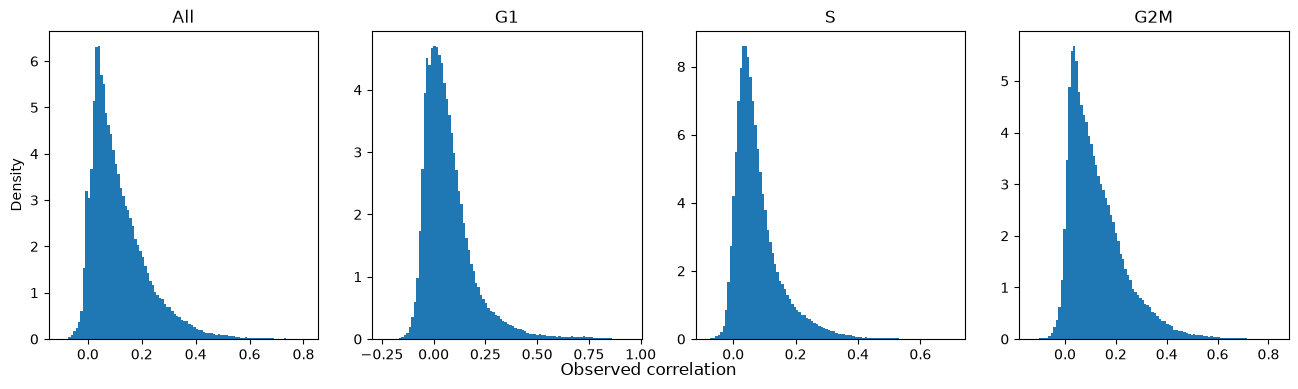

In [31]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, phase in enumerate(["All", "G1", "S", "G2M"]):
    axs[i].hist(
        corr_df[[f'{miRNA}_{phase}_OB' for miRNA in adata_miRNA.var['GeneName']]].values.flatten(),
        bins=100,
        density=True
    )
    axs[i].set_title(phase)
fig.supxlabel("Observed correlation")
axs[0].set_ylabel("Density")
plt.show()

## Interaction %

In [109]:
# select all categories
miRNA_names = adata_miRNA.var['GeneName'].tolist()
phase_names = ["All", "G1", "S", "G2M"]

# table of miRNA x phases
ind_table = pd.DataFrame(
    index=["Total"] + miRNA_names,
    columns=phase_names,
    dtype=float
)

# fill
for phase in phase_names:
    for miRNA in miRNA_names:
        ind_table.loc[miRNA, phase] = (MF_ind_df[f'{miRNA}_{phase}_status'] == "INFEASIBLE").mean() * 100
    ind_table.loc['Total', phase] = ind_table.loc[miRNA_names, phase].mean()

# display
ind_table.style.format(precision=2).background_gradient(axis=1, cmap="Blues")

,All,G1,S,G2M
Total,20.43,15.43,8.56,8.62
MIR3917,0.63,38.01,0.87,0.58
MIR5087,2.29,11.74,0.98,1.18
MIR3658,18.37,11.06,4.19,4.75
MIR4426,22.42,13.51,11.27,4.96
MIR4444-1,10.47,5.47,1.17,3.33
MIR1244-1,20.34,12.52,10.12,5.23
MIR3655,9.22,6.49,3.22,2.47
MIR4647,7.20,11.84,1.63,1.71
MIR3654,29.50,8.80,4.14,2.53


Heatmap per row (miRNA / total over phases)
- overall dependence reduced when conditioning on cell cycle phase (total)
- G1 most active phase
    - However, also fewest cells so easiest to have spurious correlations due to single outliers, etc
- some miRNA much more active than others

## Correlation midpoint

In [ ]:
all_corr = MF_int_df[[col for col in MF_int_df.columns if "All_HAR_mid" in col]].values.flatten()
all_corr = all_corr[~np.isnan(all_corr)]

G1_corr = MF_int_df[[col for col in MF_int_df.columns if "G1_HAR_mid" in col]].values.flatten()
G1_corr = G1_corr[~np.isnan(G1_corr)]

S_corr = MF_int_df[[col for col in MF_int_df.columns if "S_HAR_mid" in col]].values.flatten()
S_corr = S_corr[~np.isnan(S_corr)]

G2M_corr = MF_int_df[[col for col in MF_int_df.columns if "G2M_HAR_mid" in col]].values.flatten()
G2M_corr = G2M_corr[~np.isnan(G2M_corr)]

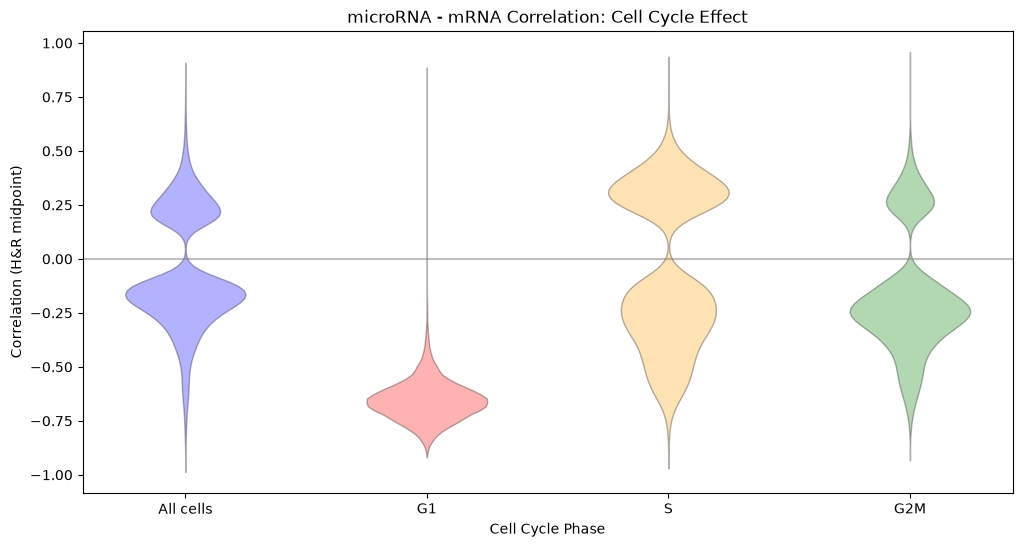

In [74]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "red", "orange", "green"]
plot_data_list = [
    all_corr,
    G1_corr,
    S_corr,
    G2M_corr
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    vp['bodies'][0].set_facecolor(plot_colors[i])
    vp['bodies'][0].set_edgecolor("black")

axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation (H&R midpoint)")
axs.set_title("microRNA - mRNA Correlation: Cell Cycle Effect")
plt.show()

## Correlation intervals

In [70]:
all_corr_lb = MF_int_df[[col for col in MF_int_df.columns if "All_HAR_min" in col]].values.flatten()
all_corr_lb = all_corr_lb[~np.isnan(all_corr_lb)]

G1_corr_lb = MF_int_df[[col for col in MF_int_df.columns if "G1_HAR_min" in col]].values.flatten()
G1_corr_lb = G1_corr_lb[~np.isnan(G1_corr_lb)]

S_corr_lb = MF_int_df[[col for col in MF_int_df.columns if "S_HAR_min" in col]].values.flatten()
S_corr_lb = S_corr_lb[~np.isnan(S_corr_lb)]

G2M_corr_lb = MF_int_df[[col for col in MF_int_df.columns if "G2M_HAR_min" in col]].values.flatten()
G2M_corr_lb = G2M_corr_lb[~np.isnan(G2M_corr_lb)]

In [71]:
all_corr_ub = MF_int_df[[col for col in MF_int_df.columns if "All_HAR_max" in col]].values.flatten()
all_corr_ub = all_corr_ub[~np.isnan(all_corr_ub)]

G1_corr_ub = MF_int_df[[col for col in MF_int_df.columns if "G1_HAR_max" in col]].values.flatten()
G1_corr_ub = G1_corr_ub[~np.isnan(G1_corr_ub)]

S_corr_ub = MF_int_df[[col for col in MF_int_df.columns if "S_HAR_max" in col]].values.flatten()
S_corr_ub = S_corr_ub[~np.isnan(S_corr_ub)]

G2M_corr_ub = MF_int_df[[col for col in MF_int_df.columns if "G2M_HAR_max" in col]].values.flatten()
G2M_corr_ub = G2M_corr_ub[~np.isnan(G2M_corr_ub)]

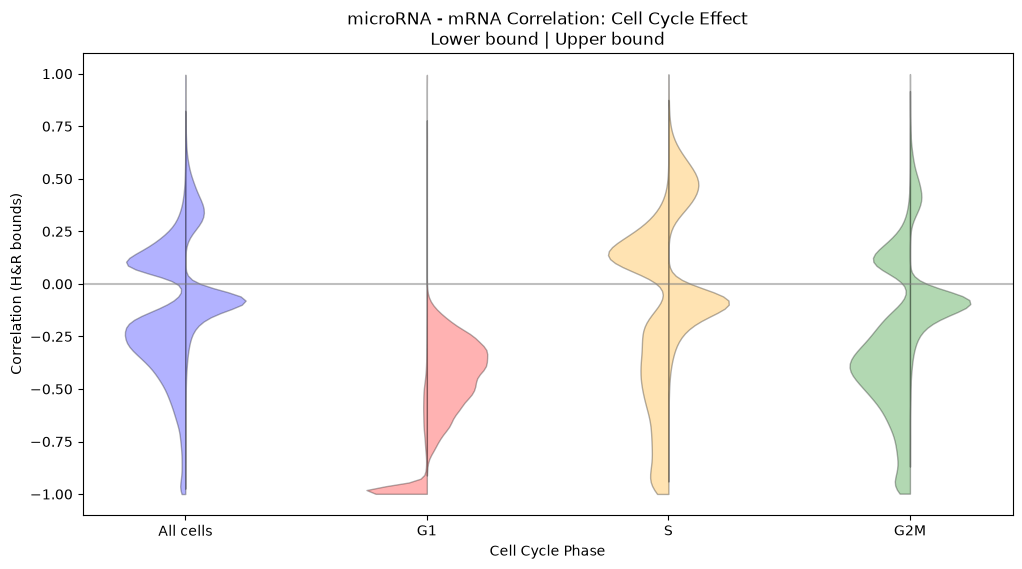

In [76]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "red", "orange", "green"]
plot_data_list_lb = [
    all_corr_lb,
    G1_corr_lb,
    S_corr_lb,
    G2M_corr_lb
]
plot_data_list_ub = [
    all_corr_ub,
    G1_corr_ub,
    S_corr_ub,
    G2M_corr_ub
]
for i, (plot_data_lb, plot_data_ub) in enumerate(zip(plot_data_list_lb, plot_data_list_ub)):
    vp = axs.violinplot(
        dataset=plot_data_lb,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor(plot_colors[i])
    vp['bodies'][0].set_edgecolor("black")
    vp = axs.violinplot(
            dataset=plot_data_ub,
            positions=[i],
            showextrema=False,
            side="high"
        )
    vp['bodies'][0].set_facecolor(plot_colors[i])
    vp['bodies'][0].set_edgecolor("black")

axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation (H&R bounds)")
axs.set_title("microRNA - mRNA Correlation: Cell Cycle Effect\nLower bound | Upper bound")
plt.show()

## Observed and Recovered

In [82]:
miRNA_names = adata_miRNA.var['GeneName'].tolist()
miRNA_names

['MIR3917',
 'MIR5087',
 'MIR3658',
 'MIR4426',
 'MIR4444-1',
 'MIR1244-1',
 'MIR3655',
 'MIR4647',
 'MIR3654',
 'MIR7705',
 'ENSG00000221184',
 'MIR3652',
 'MIR4709',
 'MIR7706',
 'MIR3178',
 'MIR632',
 'MIR4741',
 'MIR1181',
 'MIR663A',
 'MIR6821']

In [83]:
all_corr_HR = MF_int_df[[f"{miRNA}_All_HAR_mid" for miRNA in miRNA_names]].values.flatten()
all_mask = ~np.isnan(all_corr_HR)
all_corr_HR = all_corr_HR[all_mask]

G1_corr_HR = MF_int_df[[f"{miRNA}_G1_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G1_mask = ~np.isnan(G1_corr_HR)
G1_corr_HR = G1_corr_HR[G1_mask]

S_corr_HR = MF_int_df[[f"{miRNA}_S_HAR_mid" for miRNA in miRNA_names]].values.flatten()
S_mask = ~np.isnan(S_corr_HR)
S_corr_HR = S_corr_HR[S_mask]

G2M_corr_HR = MF_int_df[[f"{miRNA}_G2M_HAR_mid" for miRNA in miRNA_names]].values.flatten()
G2M_mask = ~np.isnan(G2M_corr_HR)
G2M_corr_HR = G2M_corr_HR[G2M_mask]

In [84]:
all_corr_OB = corr_df[[f"{miRNA}_All_OB" for miRNA in miRNA_names]].values.flatten()
all_corr_OB_int = all_corr_OB[all_mask]

G1_corr_OB = corr_df[[f"{miRNA}_G1_OB" for miRNA in miRNA_names]].values.flatten()
G1_corr_OB_int = G1_corr_OB[G1_mask]

S_corr_OB = corr_df[[f"{miRNA}_S_OB" for miRNA in miRNA_names]].values.flatten()
S_corr_OB_int = S_corr_OB[S_mask]

G2M_corr_OB = corr_df[[f"{miRNA}_G2M_OB" for miRNA in miRNA_names]].values.flatten()
G2M_corr_OB_int = G2M_corr_OB[G2M_mask]

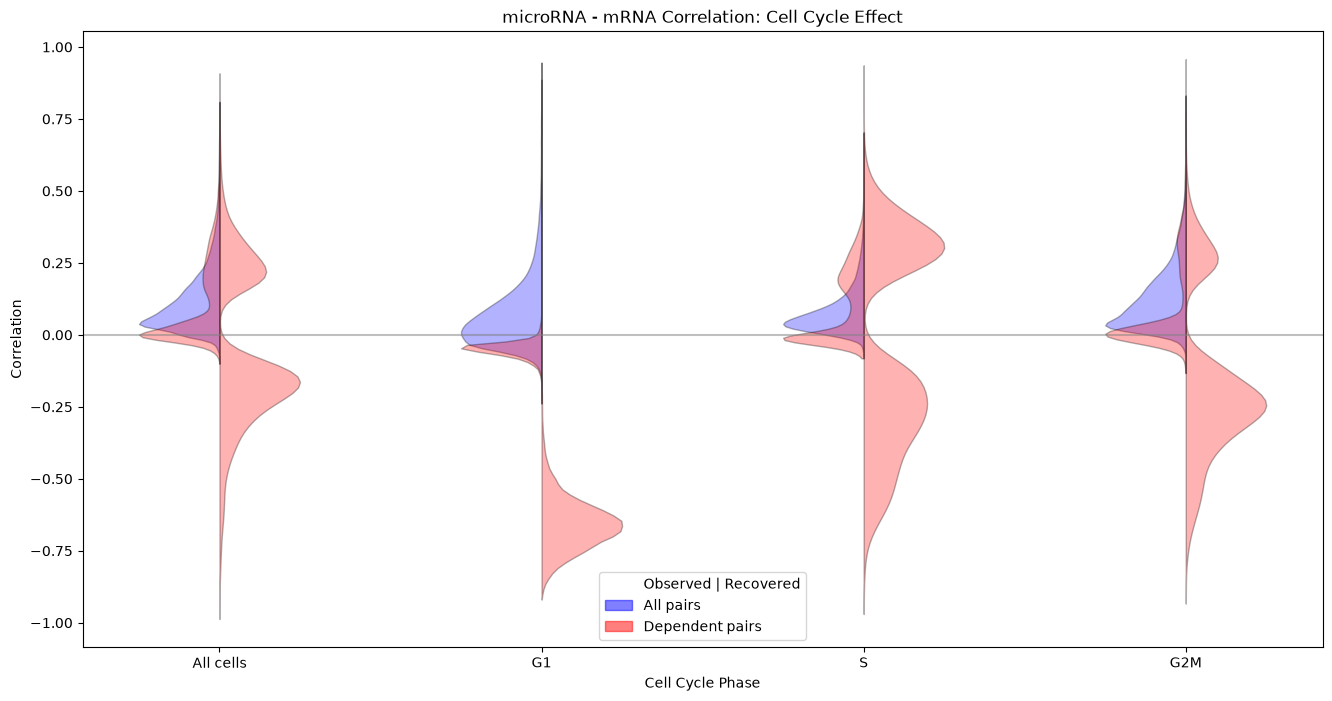

In [85]:
fig, axs = plt.subplots(figsize=(16, 8))

# all observed
plot_data_list = [
    all_corr_OB,
    G1_corr_OB,
    S_corr_OB,
    G2M_corr_OB
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("blue")
    vp['bodies'][0].set_edgecolor("black")

# interacting observed
plot_data_list = [
    all_corr_OB_int,
    G1_corr_OB_int,
    S_corr_OB_int,
    G2M_corr_OB_int
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="low"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")

# interacting recovered
plot_data_list = [
    all_corr_HR,
    G1_corr_HR,
    S_corr_HR,
    G2M_corr_HR
]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="high"
    )
    vp['bodies'][0].set_facecolor("red")
    vp['bodies'][0].set_edgecolor("black")


plt.axvspan(0, 0, 0, 0, color="white", label="Observed | Recovered")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="blue", label="All pairs")
plt.axvspan(0, 0, 0, 0, alpha=0.5, color="red", label="Dependent pairs")
axs.legend()

axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["All cells", "G1", "S", "G2M"])
axs.set_xlabel("Cell Cycle Phase")
axs.set_ylabel(f"Correlation")
axs.set_title("microRNA - mRNA Correlation: Cell Cycle Effect")
plt.show()

## Networks

In [111]:
import igraph as ig

In [210]:
# get interacting mask and correlations
int_mask = (MF_ind_df == "INFEASIBLE").values
corrs = MF_int_df[[f'{miRNA}_G1_HAR_mid' for miRNA in miRNA_names]].values

# reduce in size
M = 1000
G = 5
int_mask = int_mask[:M, :G]
corrs = corrs[:M, :G]

# reduce to mRNA with [k, K] interations
k = 1
K = 20
mRNA_mask = (int_mask.sum(axis=1) >= k) & (int_mask.sum(axis=1) <= K)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# reduce to mRNA with at least d correlations above threshold t
d = 1
t = 0.1
mRNA_mask = (((corrs > t) | (corrs < -t)).sum(axis=1) >= d)
int_mask = int_mask[mRNA_mask, :]
corrs = corrs[mRNA_mask, :]

# size
N_mRNA, N_miRNA = int_mask.shape

# construct edges
idxs = np.where(int_mask)
edges = [(int(j), N_miRNA + int(i)) for i, j in zip(*idxs)]

# get edge correlations
corrs = corrs[idxs]

In [211]:
# total vertices
vertices = N_miRNA + N_mRNA

# color, label, size different for miRNA vs mRNA
vertex_color = ["orange"] * N_miRNA + ["green"] * N_mRNA
vertex_size = [30] * N_miRNA + [10] * N_mRNA
vertex_label = miRNA_names[:G] + [None] * N_mRNA

# edge width: constant or can relate to correlation strength
edge_width = [2 for c in corrs] # int(abs(c) * 10)

# edge color: red for negative, blue for positive, alpha of strength
edge_color = [(1, 0, 0, np.sqrt(-c)) if c < 0 else (0, 0, 1, np.sqrt(c)) for c in corrs]

# display size
print(f"{len(edges)} edges between {vertices} vertices")

# construct graph
g = ig.Graph(vertices, edges)

405 edges between 383 vertices


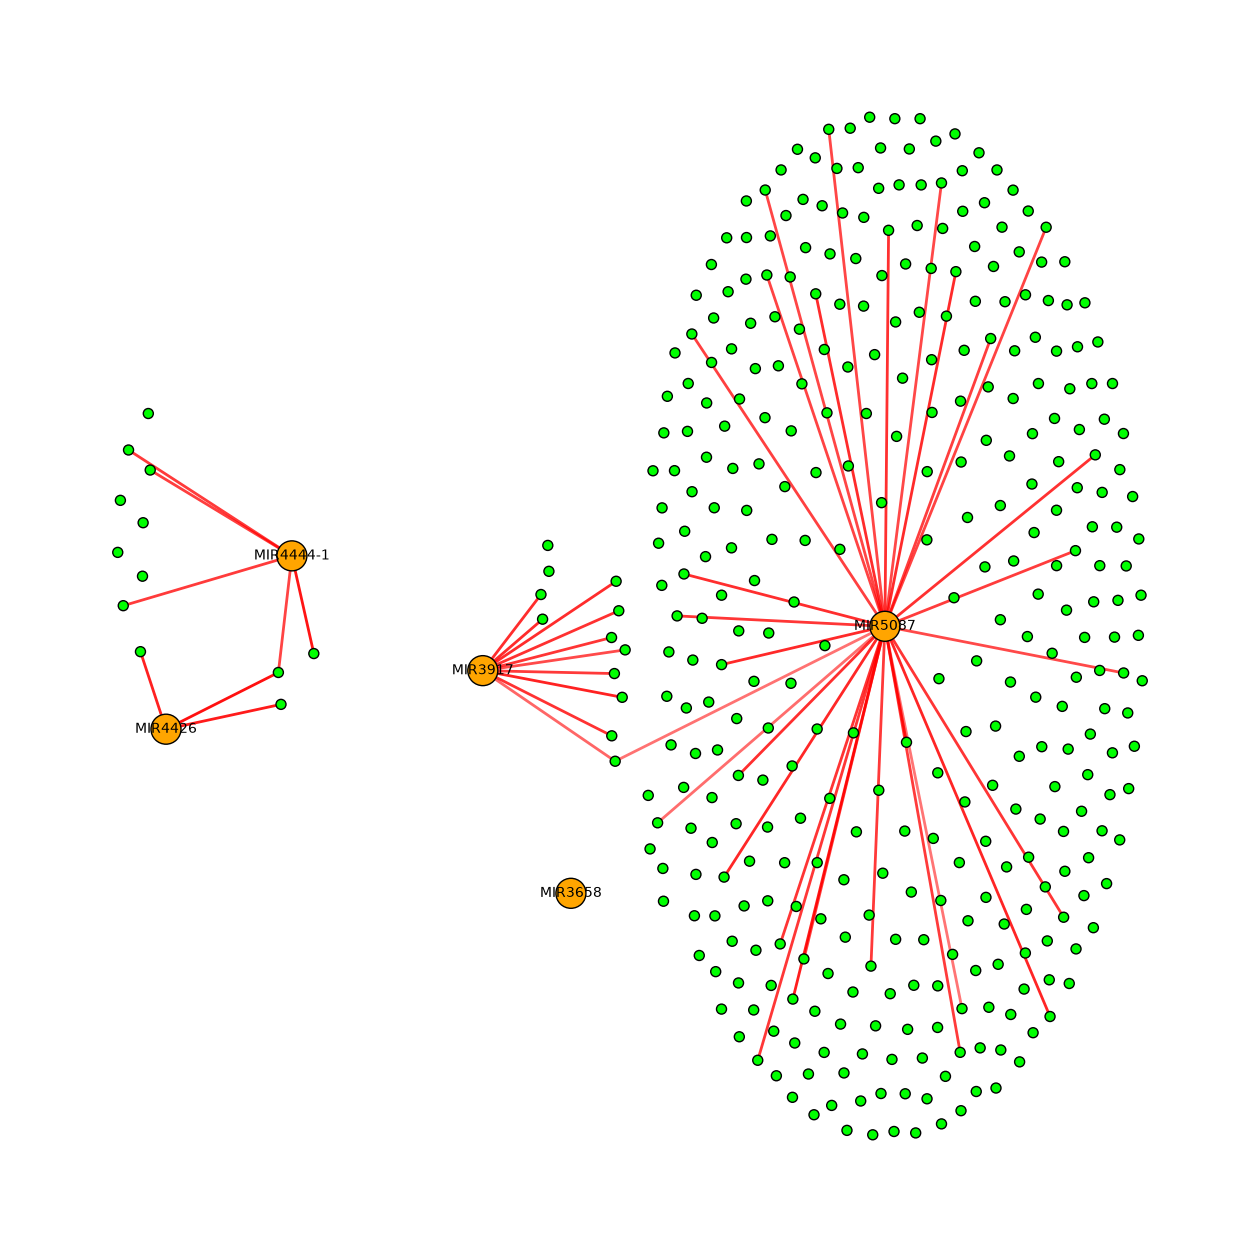

In [212]:
fig, axs = plt.subplots(figsize=(16, 16))
ig.plot(
    g,
    target=axs,
    #layout="large", # node layout algorithm
    vertex_size=vertex_size,
    vertex_color=vertex_color,
    vertex_frame_width=1,
    vertex_label=vertex_label,
    vertex_label_size=10,
    edge_width=edge_width,
    edge_color=edge_color
)
plt.show()

In [352]:
# settings
G1 = np.array([x for x in range(0, 10)])
G2 = np.arange(200)
k, K = 1, 20
d, D = 1, 20
t = 0.0

# select named miRNA & mRNA
miRNA_names = adata_miRNA.var['GeneName'].iloc[G1].tolist()
mRNA_names = adata_pcRNA.var['GeneName'].iloc[G2].tolist()

corr_df = MF_int_df.loc[mRNA_names, [f'{miRNA}_G2M_HAR_mid' for miRNA in miRNA_names]]

# select mRNA with [k, K] interactions
mask = (k <= corr_df.notna().sum(axis=1)) & (corr_df.notna().sum(axis=1) <= K)
corr_df = corr_df[mask]

# select mRNA with [d, D] interactions above threshold t
mask_thresh = ((t <= corr_df) | (corr_df <= -t)).sum(axis=1)
mask = (d <= mask_thresh) & (mask_thresh <= D)
corr_df = corr_df[mask]

# size
N_mRNA, N_miRNA = corr_df.shape
corrs = np.array(corr_df)

# construct edges
idxs = np.where(~np.isnan(corrs))
edges = [(int(j), N_miRNA + int(i)) for i, j in zip(*idxs)]

# get edge correlations
corrs = corrs[idxs]

# total vertices
vertices = N_miRNA + N_mRNA

# color, label, size different for miRNA vs mRNA
vertex_color = ["orange"] * N_miRNA + ["black"] * N_mRNA
vertex_size = [30] * N_miRNA + [5] * N_mRNA
vertex_label = miRNA_names + [None] * N_mRNA

# edge width: constant or can relate to correlation strength
edge_width = [2 for c in corrs] # int(abs(c) * 10)

# edge color: red for negative, blue for positive, alpha of strength
edge_color = [(1, 0, 0, -c) if c < 0 else (0, 0, 1, c) for c in corrs]

# display size
print(f"{len(edges)} edges between {vertices} vertices")

# construct graph
g = ig.Graph(vertices, edges)

28 edges between 24 vertices


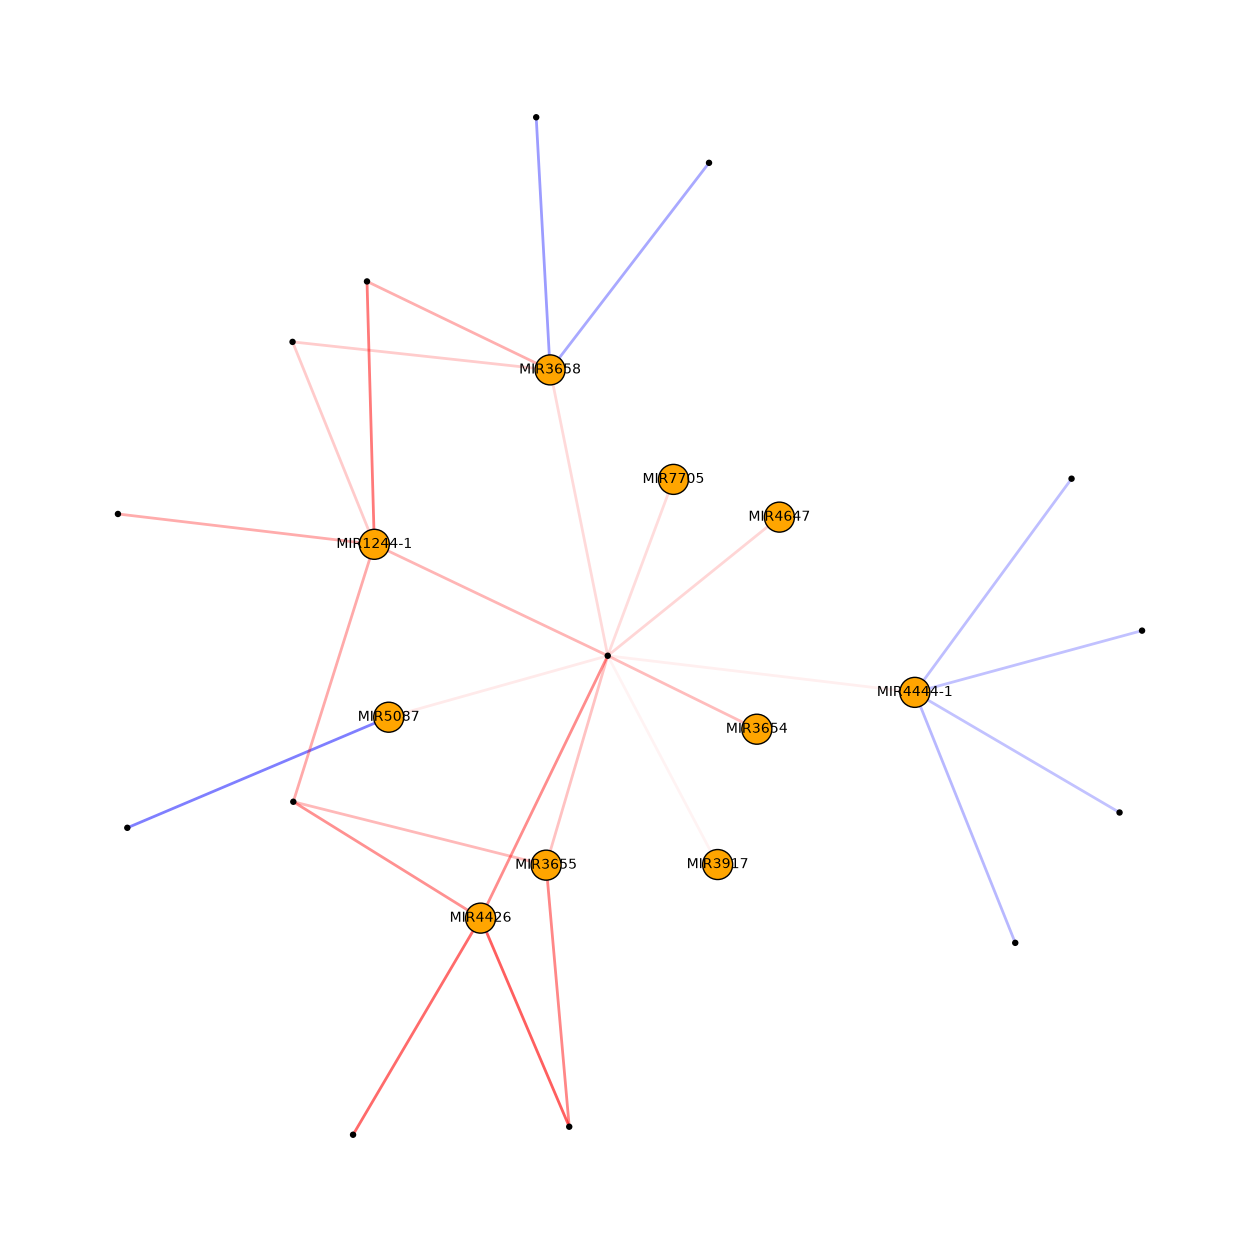

In [353]:
fig, axs = plt.subplots(figsize=(16, 16))
ig.plot(
    g,
    target=axs,
    #layout="large", # node layout algorithm
    vertex_size=vertex_size,
    vertex_color=vertex_color,
    vertex_frame_width=1,
    vertex_label=vertex_label,
    vertex_label_size=10,
    edge_width=edge_width,
    edge_color=edge_color
)
plt.show()

# TODO

- change network code to allow any miRNA selection
- fix mRNA target selection to properly select interating targets
- produce plots of a small miRNA selection and their changing target network over phases

# mRNA - mRNA correlations

- look at correlations between target mRNA
- storage
    - maybe change to be single dataframe with index the name pair and columns the status / correlation results
    - can potentially construct full sparse matrix of miRNA + mRNA correlations